In [1]:
#ResearchAssignment
#Laine Kowalski
#ASTR 400B
#CANT HAVE LISTS AT ALL only arrays or 5 points docked

"""
Average Specific Angular Momentum of Milky Way and Andromeda Merged Dark Matter Halo Analysis:
--------------------------------------------------------

GOAL: This code will investigate the dynamics of the merged dark matter halo vs 
what the MW halo and M31 halo dynamics were before the merger. The
code picks two points in time, one before the galaxies begin to merge 
(Snapshot 0) and one after the merger (Snapshot 680). Then,
the code will compute the average angular momentum of MW, M31 and the
merged Milkdromeda dark matter halo at different radii to observe when ave ang mom peaks.
The code will then compare the three results to see if the 
profiles are similar/different and the reason why will be explored.
"""

"""
RESEARCH QUESTIONS:
What is the average specific angular momentum as radius increases post-merger? 
Is it the same or different than the peak specific absolute average angular momentum of the dark matter halos 
in either galaxy before they merged and why?
"""

"""
BASIC OUTLINE:
# Import functions and libraries
# Read in of the simulation files
# Origin of the coordinate system is arbitrary at some location 
#Compute COM's of MW and M31 individually first
#Compute angular momentum of MW and M31 dark matter halo particles individually
#Find COM of Milkdromeda at around more than 6.7 Gyrs (Snapshot 680) - still have to code this
#Compute angular momentum of halo particles wrt COM position of each particle as a function of the radius
and averaged them within radius shells
    #L = m*(r_CM x v_CM) 
#Making plots of MW, M31 and Milkdromeda average angular momentum as a function
of radii and then compare them
#Overplot all three curves and get the peak values of average angular momentum and at what radii for all three

#**HYPOTHESIS - After the dark matter halos merge into one, the peak specific average angular momentum will occur
at a further radius from the center than compared to the two unmerged, individual galaxies 
and will have a greater magnitude. The literature states transfer of angular momentum after mergers move 
from the central regions to the "periphery" and increase the specific angular momentum.
"""


"""
MAIN FUNCTIONS:

***ComputeAngMom(MergerSnapshot, delta_r):
---------------------------------------
This function calculates the specific average angular momentum of the dark matter halos of MW, M31, and Milkdromeda 
across different radial shells. 

It starts by determining the center of mass (COM) for the MW and M31 halos using Snapshot 0 
for the pre-merger. For each galaxy, it computes the COM position and velocity, then iterates through defined 
radial bins (from an inner radius r_lower to an outer radius r_upper, increased by delta_r each loop). 
Within each radial shell, it calculates the average angular momentum of the halo 
particles. This is repeated for each galaxy independently pre-merger and for Milkdromeda (post-merger).

***Ave_L(data_in, r_COM, v_COM, r_lower, r_upper):
-----------------------------------------------
This function calculates specific average angular momentum for particles within a radial shell around 
the COM of a galaxy. It filters the particles that are within the radial bounds (r_lower to r_upper) and computes their position 
and velocity relative to the galaxy's COM. The specific angular momentum for these particles is then calculated using 
the cross product of the relative position and velocity vectors, and is scaled by the particle type 1 mass. 
Then, it averages these values to get the mean specific angular momentum vector for the shell.



OVERALL GOAL:
*Both of these functions work together to build the radial profile of angular momentum for each galaxy both 
before and after their merger.

PLOTS:
For all objects within a bin radii (everything within some delta), I can find
all angular momentum and find the average. So, this will be computed for
many bins to get a scatter plot of Ave Ang Mom vs Radii profile pre (MW, M31) and post merger (Milkdromeda).

"""

"\nMAIN FUNCTIONS:\n\n***ComputeAngMom(MergerSnapshot, delta_r):\n---------------------------------------\nThis function calculates the specific average angular momentum of the dark matter halos of MW, M31, and Milkdromeda \nacross different radial shells. \n\nIt starts by determining the center of mass (COM) for the MW and M31 halos using Snapshot 0 \nfor the pre-merger. For each galaxy, it computes the COM position and velocity, then iterates through defined \nradial bins (from an inner radius r_lower to an outer radius r_upper, increased by delta_r each loop). \nWithin each radial shell, it calculates the average angular momentum of the halo \nparticles. This is repeated for each galaxy independently pre-merger and for Milkdromeda (post-merger).\n\n***Ave_L(data_in, r_COM, v_COM, r_lower, r_upper):\n-----------------------------------------------\nThis function calculates specific average angular momentum for particles within a radial shell around \nthe COM of a galaxy. It filters t

In [2]:
# Importing modules
import numpy as np
import astropy.units as u
from astropy.constants import G

# Import plotting modules
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

# Importing HW modules
from ReadFile import Read

# Modified CenterOfMass function so that COM_P now takes a parameter specifying 
#by how much to decrease rmax instead of a factor of 2
from CenterOfMass2 import CenterOfMass

Calculating COM wrt R and V for Galaxies

The ComputeAngMom function utilizes this equation to compute the Center of Mass with respect to r and v for each galaxy, pre and post merger. My code calculate the center of mass position rCOM using the equation for center of mass, where ri is the position vector of particle i, and N is the total number of particles within a maximum radius, Rmax. To improve accuracy, the code iteratively reduces Rmax and recalculates rCOM until the value converges, or stops changing. This method ensures a stable center of mass for both pre- and post-merger galaxies, which is necessary for calculating angular momentum relative. 

$$\mathbf{r}_{\mathrm{COM}}=\sum_{i=1}^N\mathbf{r}_{i}$$

In [3]:
#Creating COM Objects for MW and M31

def ComputeAngMom(MergerSnapshot, r_vir_MW, r_vir_M31, delta_r):
    """
    This function computes the profile of the specific average angular momentum of the dark matter halos for the MW, M31 
    premerger and the combined system post merger, Milkdromeda. It calculates the specific average angular momentum of the dark matter halos of MW, M31, and Milkdromeda 
    across different radial shells. It starts by determining the center of mass (COM) for the MW and M31 halos using Snapshot 0 
    for the pre-merger. For each galaxy, it computes the COM position and velocity, then iterates through defined 
    radial bins (from an inner radius r_lower to an outer radius r_upper, increased by delta_r each loop). 
    Within each radial shell, it calculates the specific average angular momentum of the halo particles. This is 
    repeated for each galaxy independently pre-merger and for Milkdromeda (post-merger).
    
    PARAMETERS:
        MergerSnapshot: 'integer' amount of time - each snapshot is around 1/100th Gyr
        r_vir_MW: 'float' used as an rmax ~400
        r_vir_M31: 'float' used as an rmax ~400
        delta_r: 'float' step size for which we calculate the angular momentum
    
    OUTPUTS:
        AngMomMW: 'array' array of the specific average angular momentum for MW
        AngMomM31: 'array' array of the specific average angular momentum for M31
        AngMomMD: 'array' array of the specific average angular momentum for MD
    """
    
    # PRE-MERGER MW:
    COM_MW_0 = CenterOfMass(filename="MW_000.txt", ptype=1) #Defining COM objects pre-merger for MW at Snapshot 0
    r_COM_MW_0 = COM_MW_0.COM_P(delta=0.1, volDec=2).value #Getting the center of mass coordinates for MW galaxy at Snapshot 0 (pre-merger). Delta acts like a tolerance (within 0.1 kpc), and volDec is the factor I am decreasing the volume by until I get convergence of COM location
    v_COM_MW_0 = COM_MW_0.COM_V(r_COM_MW_0[0] * u.kpc, r_COM_MW_0[1] * u.kpc, r_COM_MW_0[2] * u.kpc).value #Storing the velocity vector of the MW COM (.value to get rid of units)

    #Setting up loop for MW halo particles
    time, total, data_MW = Read("MW_000.txt") #reading in data in the given file using Read function at Snapshot 0
    index = np.where(data_MW["type"] == 1) #create an index object for ptype=1 (Halo particles)/finding rows where ptype=1 in data
    data_MW = data_MW[index] #limiting to particles whose ptype=1 in the array

    r_lower = 0 #initializing the lower radius
    r_vals = np.arange(r_lower, r_vir_MW, delta_r) #setting up array for radii
    AngMomMW = np.zeros((len(r_vals)-1,3)) #set up array to store ang mom, length by 3 filled with 0's
    
    #Looping over all shells of upper and lower radius and condition to tell it when to stop looping
    for i in range(len(r_vals) - 1):
        L = Ave_L(data_MW, r_COM_MW_0, v_COM_MW_0, r_vals[i], r_vals[i+1])
        AngMomMW[i] = L #calls and return Ave_L function, returning L's for that radius

        
        
    #PRE-MERGER M31:
    COM_M31_0 = CenterOfMass(filename="M31_000.txt", ptype=1) #Defining COM objects pre-merger for M31 at Snapshot 0
    r_COM_M31_0 = COM_M31_0.COM_P(delta=0.1,volDec = 4).value  #Getting the center of mass coordinates for M31 galaxy at Snapshot 0 (pre-merger). Delta is like a tolerance - within 0.1 kpc, and volDec is the factor we are decreasing the volume until we get convergence of COM location
    v_COM_M31_0 = COM_M31_0.COM_V(r_COM_M31_0[0]*u.kpc, r_COM_M31_0[1]*u.kpc, r_COM_M31_0[2]*u.kpc).value #Storing the velocity vector of the M31 COM (.value to get rid of units)
    
    #Setting up loop for M31 halo particles 
    time, total, data_M31 = Read("M31_000.txt") #Reading in data in the given file using Read function at Snapshot 0                              
    index = np.where(data_M31['type'] == 1) #create an index object for ptype=1 (Halo particles)/find rows where ptype=1 in data
    data_M31 = data_M31[index] #limiting to particles whose ptype=1 in the array
    
    r_lower = 0 #initializing the lower radius
    r_vals = np.arange(r_lower, r_vir_M31, delta_r) #setting up array for radii
    AngMomM31 = np.zeros((len(r_vals)-1,3)) #set up array to store ang mom, length by 3 filled with 0's
    
    #Looping over all shells of upper and lower radius and condition to tell it when to stop looping
    for i in range(len(r_vals) - 1):
        L = Ave_L(data_M31, r_COM_M31_0, v_COM_M31_0, r_vals[i], r_vals[i+1])
        AngMomM31[i] = L #calls and return Ave_L function, returning L's for that radius

    
    
    #POST-MERGER MILKDROMEDA:
    #Snapshot post merger: Inputs to reconstruct the filenames
    # add a string of the filenumber to the value “000” 
    ilbl = '000' + str(MergerSnapshot)
    # remove all but the last 3 digits
    ilbl = ilbl[-3:]
    MWfilename="MW/MW_%s"%ilbl + '.txt'
    M31filename="M31/M31_%s"%ilbl + '.txt'
    MDfilename="MD_%s"%ilbl + '.txt'
    
    #Read in files for M31:
    time, MWtotal, data_MW = Read(MWfilename) 
    time, M31total, data_M31 = Read(M31filename) 
    #creating new Milkdromeda file
    with open(MDfilename, 'w') as f: #open this file for writing and then write to it
        f.write(f"Time       {time.value}\n")
        f.write(f"Total       {MWtotal+M31total}\n")
        f.write("mass in 1e10,  x, y, z, in kpc and vx, vy, vz in km/s\n")
        f.write("#type, m, x, y, z, vx, vy, vz\n")
        index = np.where(data_M31['type'] == 1) #find rows where ptype=1 in data
        data_M31 = data_M31[index] #limiting to particles whose ptype=1 in the array
        masses = data_M31["m"]
        types = data_M31["type"]
        xvals = data_M31["x"]
        yvals = data_M31["y"]
        zvals = data_M31["z"]
        vxvals = data_M31["vx"]
        vyvals = data_M31["vy"]
        vzvals = data_M31["vz"]
        
       #creating the rows/headers for M31 post merger
        for i in range(len(masses)):
            f.write(f"    {types[i]}    {masses[i]}    {xvals[i]}    {yvals[i]}    {zvals[i]}    {vxvals[i]}    {vyvals[i]}    {vzvals[i]}\n")

    #for MW
        index = np.where(data_MW['type'] == 1) #find rows where ptype=1 in data
        data_MW = data_MW[index] #limiting to particles whose ptype=1 in the array
        masses = data_MW["m"]
        types = data_MW["type"]
        xvals = data_MW["x"]
        yvals = data_MW["y"]
        zvals = data_MW["z"]
        vxvals = data_MW["vx"]
        vyvals = data_MW["vy"]
        vzvals = data_MW["vz"]
        
        #creating the rows/headers for MW post merger
        for i in range(len(masses)):
            f.write(f"    {types[i]}    {masses[i]}    {xvals[i]}    {yvals[i]}    {zvals[i]}    {vxvals[i]}    {vyvals[i]}    {vzvals[i]}\n")
    
    COM_MD = CenterOfMass(filename=MDfilename, ptype=1) #Defining COM objects pre-merger for M31 at Snapshot post merger
    r_COM_MD = COM_MD.COM_P(delta=0.1,volDec=2).value #Getting the center of mass coordinates for M31 galaxy at Snapshot 0 (pre-merger). Delta is like a tolerance - within 0.1 kpc, and volDec is the factor we are decreasing the volume until we get convergence of COM location
    v_COM_MD = COM_MD.COM_V(r_COM_MD[0]*u.kpc, r_COM_MD[1]*u.kpc, r_COM_MD[2]*u.kpc).value #Storing the velocity vector of the M31 COM (.value to get rid of units)
    
    #Setting up loop for MD halo particles post-merger
    time, total, data_MD = Read(MDfilename) #Reading in data in the given file using Read function at Snapshot 0                             
    index = np.where(data_MD['type'] == 1) #create an index object for ptype=1 (Halo particles). find rows where ptype=1 in data
    data_MD = data_MD[index] #limiting to particles whose ptype=1 in the array
    
    r_lower = 0 #initializing the lower radius
    r_vals = np.arange(r_lower, r_vir_MW, delta_r) #setting up array for radii
    AngMomMD = np.zeros((len(r_vals)-1,3)) #set up array to store ang mom, length by 3 filled with 0's
    
    #Looping over all shells of upper and lower radius and condition to tell it when to stop looping
    for i in range(len(r_vals) - 1):
        L = Ave_L(data_MD, r_COM_MD, v_COM_MD, r_vals[i], r_vals[i+1])
        AngMomMD[i] = L #calls and return Ave_L function, returning L's for that radius

        
    return AngMomMW, AngMomM31, AngMomMD

Calculating Specific Average Angular Momentum

This absolute average angular momentum equation is the end computation calculated in the Ave_L function below. To compute the absolute average angular momentum |Lave(r)| at a given radius r, the code calculates the cross product of position and velocity vectors for particles within a radial bin (r−δ,r+δ), relative to the system’s center of mass (COM). Each term $(\mathbf{r}_i - \mathbf{r}_{\text{COM}}) \times (\mathbf{v}_i - \mathbf{v}_{\text{COM}})$ gives the specific angular momentum of particle i, which is averaged over all Nstar particles in the bin and multiplied by the mass, m, of particle type 1. This equation in the code computes average angular momentum at different radii, helping to reveal the rotational structure/dynamical evolution of the dark matter halo.

$$|\mathbf{L}_{\mathrm{ave}} (\mathbf{r})| = m\sum_{\mathbf{r}_{i}\in(\mathbf{r}-\boldsymbol{\delta})}^{(\mathbf{r}+\boldsymbol{\delta})}\frac{1}{N_\ast}(\mathbf{r}_{i}-\mathbf{r}_{\mathrm{COM}})\boldsymbol{\times}(\mathbf{v}_{i}-\mathbf{v}_{\mathrm{COM}})$$

In [4]:
def Ave_L(data_in, r_COM, v_COM, r_lower, r_upper):
    """
    This function calculates specific average angular momentum for particles within a specific radial shell around 
    the COM of a galaxy. It filters the particles that are within the radial bounds (r_lower to r_upper) and computes their position 
    and velocity relative to the galaxy's COM. The angular momentum for these particles is then calculated using 
    the cross product of the relative position and velocity vectors, and is scaled by the particle type 1 mass. 
    Then, it averages these values to get the mean angular momentum vector for the shell.
    
    PARAMETERS:
        data: "array" - Array that contains all simulation data
        r_COM: "vector" - position vector of the COM of some galaxy
        v_COM: "vector" - velocity vector of the COM of some galaxy
        r_lower: "float" - lower radius of the bin under consideration
        r_upper: "float" - upper radius of the bin under consideration
        
    OUTPUTS:
        Lx_ave: x-comp of the specific average angular momentum within a bin
        Ly_ave: y-comp of the specific average angular momentum within a bin
        Lz_ave: z-comp of the specific average angular momentum within a bin
    """
    data = np.copy(data_in) #make a copy of object, modify copy without changing object

    # store the mass, positions, velocities of only the particles of the given type - Refering to all positions/velocities (x,y,z) for ptype=1
    m = data["m"]
    x = data["x"]
    y = data["y"]
    z = data["z"]
    vx = data["vx"]
    vy = data["vy"]
    vz = data["vz"]

    #Computing relative position magnitude (distance) from the COM
    r = np.sqrt((x - r_COM[0]) ** 2 + (y - r_COM[1]) ** 2 + (z - r_COM[2]) ** 2)

    #Creating a bin index to get the particles within the delta/bin that we want/Finding rows in data files that match these conditions
    condition1 = r >= r_lower
    condition2 = r <= r_upper
    comb_conditions = np.logical_and(condition1, condition2)
    bin_index = np.where(comb_conditions)

    m = m[bin_index] #grabbing mass of individual particles in a bin
    #Redefine positions and velocities to be the new positions and velocities wrt to the COM, so I subtract COM off
    x = x[bin_index] - r_COM[0]
    y = y[bin_index] - r_COM[1]
    z = z[bin_index] - r_COM[2]
    vx = vx[bin_index] - v_COM[0]
    vy = vy[bin_index] - v_COM[1]
    vz = vz[bin_index] - v_COM[2]
    num_particles = np.size(bin_index)

    #Compute the absolute value of the specific angular momentum of each individual particle within a bin
    #Summed the specific angular momentums and then divide by the particle number to get the specific ang mom
    #Boolean statement ensures we do not get an error dividing by 0 when there is no mass left to loop over
    if num_particles != 0:
        L = (np.sum(np.cross([x, y, z], [vx, vy, vz], axisa=0, axisb=0), axis=0) / num_particles)
    else:
        L = np.zeros((3)) #getting a shape of [0,0,0] for Lx,Ly,Lz

    return L

In [5]:
# Calling the function to get arrays
AngMomMW, AngMomM31, AngMomMD = ComputeAngMom(MergerSnapshot=680, r_vir_MW=400, r_vir_M31=400, delta_r=1)

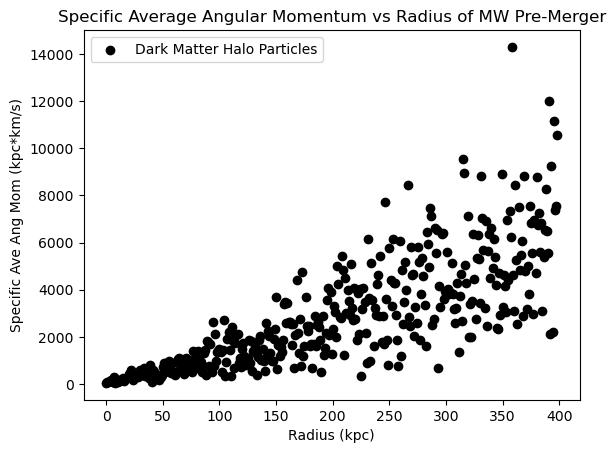

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# creating an array of radii so that historgram bins are centered
radii = np.arange(0, 399, step=1)

# creating MW pre merger plot
fig, ax = plt.subplots()
aam_MW = np.sqrt(AngMomMW[:, 0] ** 2 + AngMomMW[:, 1] ** 2 + AngMomMW[:, 2] ** 2)
ax.scatter(radii, aam_MW, label="Dark Matter Halo Particles", color="black")

plt.title("Specific Average Angular Momentum vs Radius of MW Pre-Merger")
ax.set_xlabel("Radius (kpc)")
ax.set_ylabel("Specific Ave Ang Mom (kpc*km/s)")
plt.legend()
plt.show()

In [7]:
#Figuring out the peak specific angular momentum around the virial radius r_vir=200
f'MW Specific Angular Momentum at Virial Radius 200kpc is: {np.mean(np.linalg.norm(AngMomMW[195:205,:], axis=1)):.2f} kpc*km/s'

'MW Specific Angular Momentum at Virial Radius 200kpc is: 3053.82 kpc*km/s'

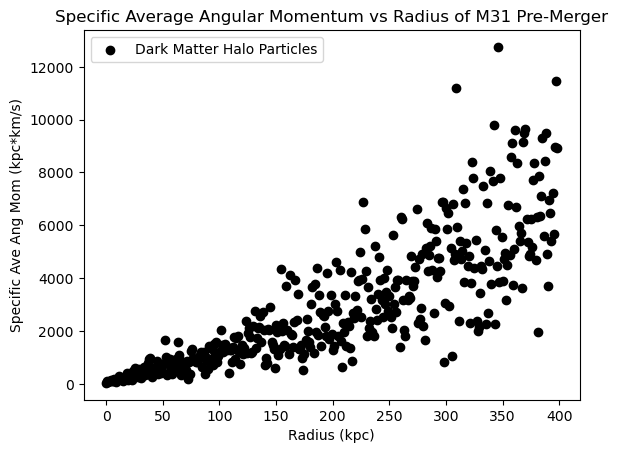

In [8]:
# creating an array of radii so that historgram bins are centered
radii = np.arange(0, 399, step=1)

# creating M31 pre merger plot
fig, ax = plt.subplots()
aam_M31 = np.sqrt(AngMomM31[:, 0] ** 2 + AngMomM31[:, 1] ** 2 + AngMomM31[:, 2] ** 2)
ax.scatter(radii, aam_M31, label="Dark Matter Halo Particles", color="black")

plt.title("Specific Average Angular Momentum vs Radius of M31 Pre-Merger")
ax.set_xlabel("Radius (kpc)")
ax.set_ylabel("Specific Ave Ang Mom (kpc*km/s)")
plt.legend()
plt.show()

In [9]:
#Figuring out the peak specific angular momentum around the virial radius r_vir=200
f'M31 Specific Angular Momentum at Virial Radius 200kpc is: {np.mean(np.linalg.norm(AngMomM31[195:205,:], axis=1)):.2f} kpc*km/s'

'M31 Specific Angular Momentum at Virial Radius 200kpc is: 2697.34 kpc*km/s'

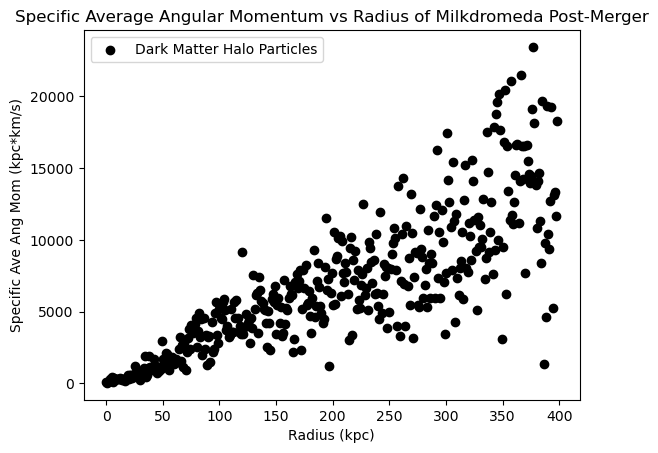

In [10]:
# creating an array of radii so that historgram bins are centered
radii = np.arange(0, 399, step=1)

# creating MD pre merger plot
fig, ax = plt.subplots()
aam_MD = np.sqrt(AngMomMD[:, 0] ** 2 + AngMomMD[:, 1] ** 2 + AngMomMD[:, 2] ** 2)
ax.scatter(radii, aam_MD, label="Dark Matter Halo Particles", color="black")

plt.title("Specific Average Angular Momentum vs Radius of Milkdromeda Post-Merger")
ax.set_xlabel("Radius (kpc)")
ax.set_ylabel("Specific Ave Ang Mom (kpc*km/s)")
plt.legend()
plt.show()

In [11]:
#Figuring out the peak specific angular momentum around the virial radius r_vir=350
f'MD Specific Angular Momentum at Virial Radius 350kpc is: {np.mean(np.linalg.norm(AngMomMD[345:355,:], axis=1)):.2f} kpc*km/s'

'MD Specific Angular Momentum at Virial Radius 350kpc is: 14009.52 kpc*km/s'